# House Price Prediction — King County, WA
### Data Science Capstone — Final Deliverable

**Name:**  Malak Adel hameed
**Topic:** Real Estate Price Prediction (Regression)
**Cohort:** DSB2

---


## Introduction

This project analyzes the **King County House Sales dataset** (Seattle, WA area), which contains
~21,600 residential property sales recorded between May 2014 and May 2015. Each record describes a
single home sale with attributes covering size, condition, location, and quality — alongside the
final sale `price`.

The capstone builds on the work from Lightning Talk #1 (topic selection) and Lightning Talk #2
(cleaning, EDA, and a modeling plan). This notebook completes the pipeline end-to-end: cleaning,
exploratory analysis, feature engineering, three modeling approaches (each improved from a basic
version), and a final recommendation. The project's final, adopted model is a **Stacking
Regressor** that combines XGBoost, LightGBM, and CatBoost.


## Problem Statement

House prices fluctuate significantly, and buyers and sellers can face substantially different
property valuations depending on factors such as living area, number of bedrooms/bathrooms,
location, condition, construction grade, waterfront view, and year built. These variations make it
difficult for buyers and sellers to judge whether a property is fairly priced.

**Aim:** Build a machine learning model that predicts a home's sale price from its physical and
location characteristics, accurate enough to support real-world pricing decisions, and identify
which features drive price the most.


## Objectives

- Which features influence house price the most (size, location, quality, age)?
- Can feature engineering (e.g. house age, distance to Seattle, location encoding) improve model
  performance beyond the raw columns?
- How do a linear model, a single gradient-boosted tree model, and a stacked ensemble of models
  compare on the same data?
- Does combining multiple boosting algorithms in a **Stacking Regressor** outperform any single
  model, and is the added complexity worth it?


## Data Dictionary

| Column | Type | Description |
|---|---|---|
| id | int | Unique house identifier |
| date | object | Date the house was sold |
| price | float | **Target.** Sale price (USD) |
| bedrooms | int | Number of bedrooms |
| bathrooms | float | Number of bathrooms |
| sqft_living | int | Living space square footage |
| sqft_lot | int | Lot square footage |
| floors | float | Number of floors |
| waterfront | int | 1 if property has a waterfront view |
| view | int | Quality of view (0–4 scale) |
| condition | int | Overall condition rating (1–5) |
| grade | int | Construction/design quality grade |
| sqft_above | int | Square footage above ground |
| sqft_basement | int | Square footage of basement |
| yr_built | int | Year house was built |
| yr_renovated | int | Year renovated (0 if never) |
| zipcode | int | Zip code |
| lat / long | float | Latitude / longitude |
| sqft_living15 | int | Avg. living space of nearest 15 neighbors |
| sqft_lot15 | int | Avg. lot size of nearest 15 neighbors |

**Engineered columns** (created during preprocessing): `is_studio`, `house_age`,
`years_since_renovation`, `sqft_ratio`, `total_rooms`, `dist_to_seattle`, `zip_encoded`,
`price_log`.


# Data Inspection

## Data Overview

**Source:** King County House Sales dataset (Seattle, WA area; originally distributed via Kaggle,
covering sales from May 2014 – May 2015). **Format:** single CSV file, one row per sale.


In [2]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('./Data/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(21613, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [6]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Data Cleaning
Handle missing values, outliers, and inconsistencies.


In [7]:
# 1. Missing values
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

There are no missing values in this dataset. The cleaning work here focuses on **data-entry errors and logical inconsistencies** instead.

Rows with bedrooms == 33 before fix: 1


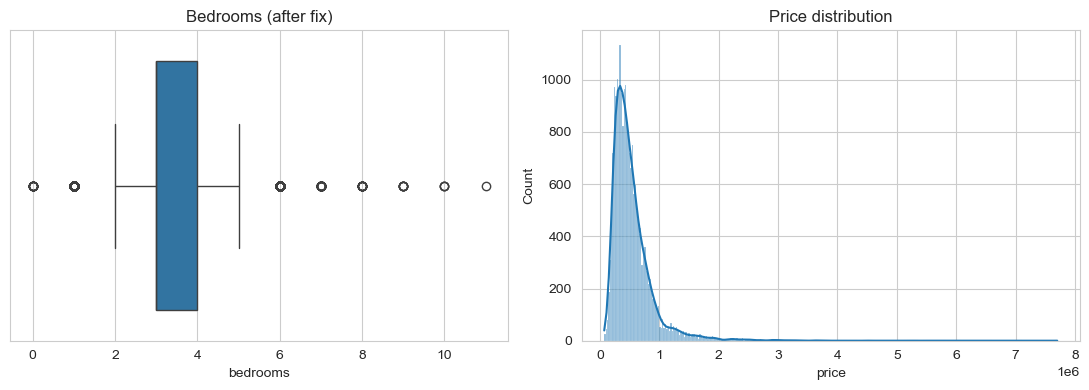

In [8]:
# 2. Fix column types
df['date'] = pd.to_datetime(df['date'])

# 3. Known data-entry error: a house listed with 33 bedrooms on ~1,620 sqft of living space.
#    This is almost certainly a typo for 3 bedrooms; we correct it rather than drop the row.
print('Rows with bedrooms == 33 before fix:', (df['bedrooms'] == 33).sum())
df.loc[df['bedrooms'] == 33, 'bedrooms'] = 3

# 4. Outlier check on bedrooms/price after the fix
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['bedrooms'], ax=axes[0]); axes[0].set_title('Bedrooms (after fix)')
sns.histplot(df['price'], kde=True, ax=axes[1]); axes[1].set_title('Price distribution')
plt.tight_layout(); plt.show()

In [9]:
# 5. Flag studio-style units (0-1 bedroom, very small living area) before imputing
#    0-bedroom listings, so this distinct segment isn't lost in later modeling.
df['is_studio'] = ((df['bedrooms'].isin([0, 1])) & (df['sqft_living'] < 600)).astype(int)
print(df['is_studio'].value_counts())

# 6. Impute 0-bedroom listings to 1 bedroom for logical/mathematical consistency
print('Rows with 0 bedrooms:', (df['bedrooms'] == 0).sum())
df.loc[df['bedrooms'] == 0, 'bedrooms'] = 1

is_studio
0    21577
1       36
Name: count, dtype: int64
Rows with 0 bedrooms: 13


# Exploratory Data Analysis (EDA)
Trends, relationships, anomalies; univariate, bivariate, and multivariate analysis.


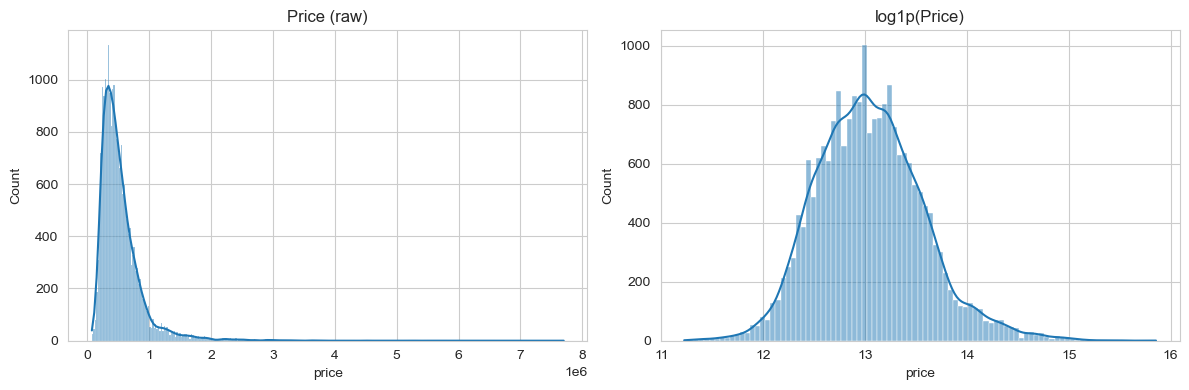

Skewness — raw price: 4.02
Skewness — log1p(price): 0.43


In [10]:
# Target distribution: price is heavily right-skewed, as expected for real-estate prices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], kde=True, ax=axes[0]); axes[0].set_title('Price (raw)')
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1]); axes[1].set_title('log1p(Price)')
plt.tight_layout(); plt.show()

print('Skewness — raw price:', df['price'].skew().round(2))
print('Skewness — log1p(price):', np.log1p(df['price']).skew().round(2))

In [11]:
# Skewness of all numeric features - identifies which variables may benefit from a log transform
skew_table = df.select_dtypes(include=np.number).drop(columns=['id']).skew().sort_values(ascending=False)
skew_table.to_frame('skewness')

,skewness
is_studio,24.442703
sqft_lot,13.060019
waterfront,11.385108
sqft_lot15,9.506743
yr_renovated,4.549493
price,4.024069
view,3.395750
sqft_basement,1.577965
sqft_living,1.471555
sqft_above,1.446664


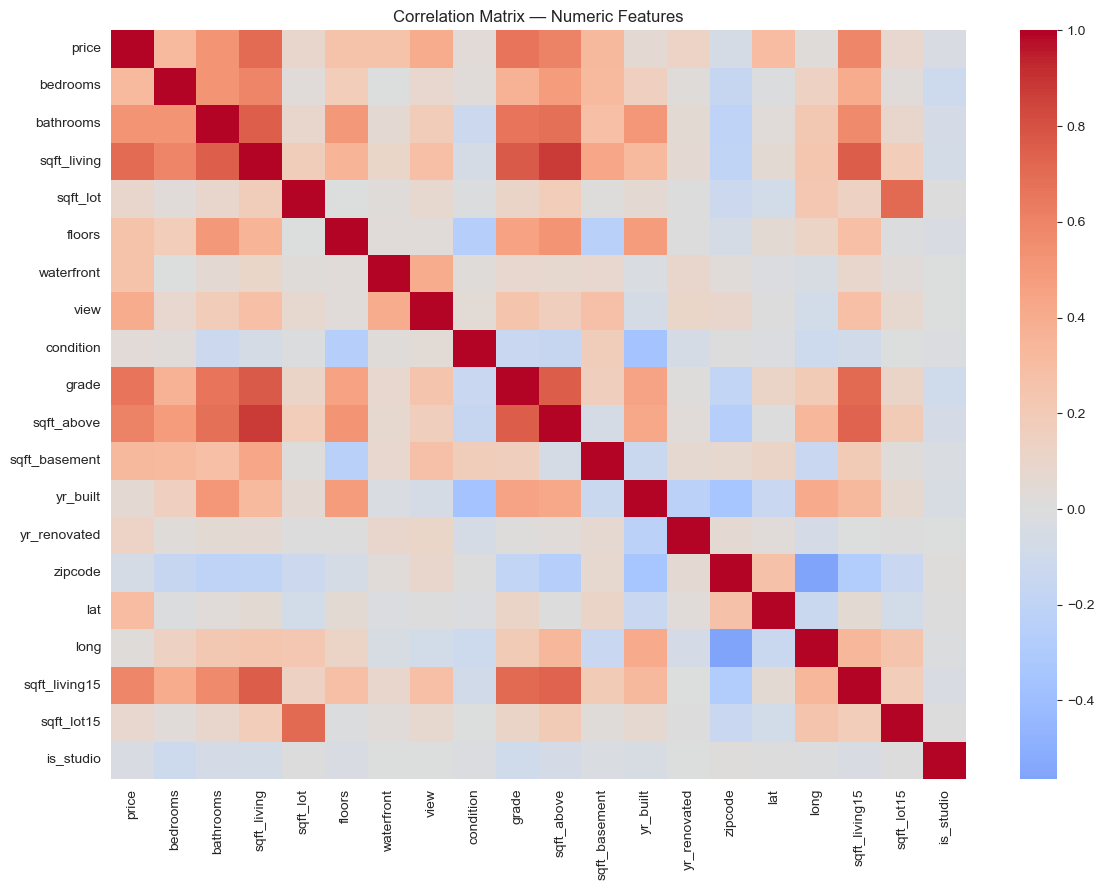

Top correlations with price:


price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.315864
lat              0.307003
Name: price, dtype: float64

In [12]:
# Correlation matrix for continuous columns
numeric_cols = df.select_dtypes(include=np.number).columns.drop(['id'])
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout(); plt.show()

print('Top correlations with price:')
corr['price'].abs().sort_values(ascending=False).head(10)

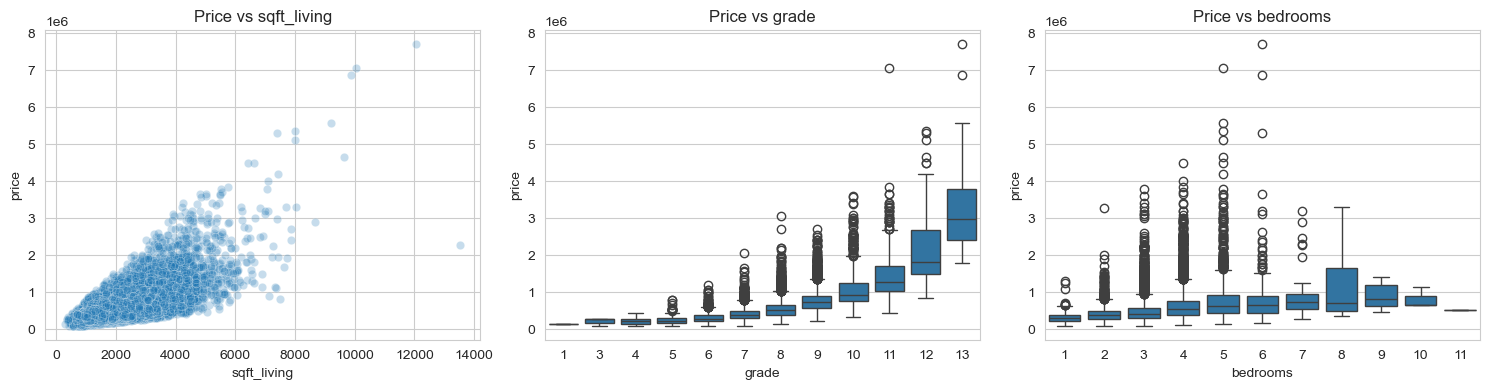

In [13]:
# Bivariate EDA: price vs. the strongest drivers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.25, ax=axes[0])
axes[0].set_title('Price vs sqft_living')
sns.boxplot(data=df, x='grade', y='price', ax=axes[1])
axes[1].set_title('Price vs grade')
sns.boxplot(data=df, x='bedrooms', y='price', ax=axes[2])
axes[2].set_title('Price vs bedrooms')
plt.tight_layout(); plt.show()

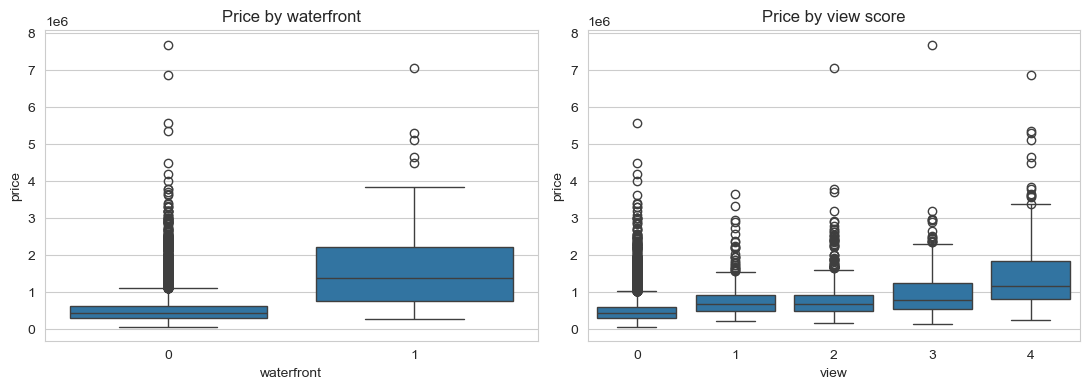

In [14]:
# Waterfront / view vs price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='waterfront', y='price', ax=axes[0]); axes[0].set_title('Price by waterfront')
sns.boxplot(data=df, x='view', y='price', ax=axes[1]); axes[1].set_title('Price by view score')
plt.tight_layout(); plt.show()

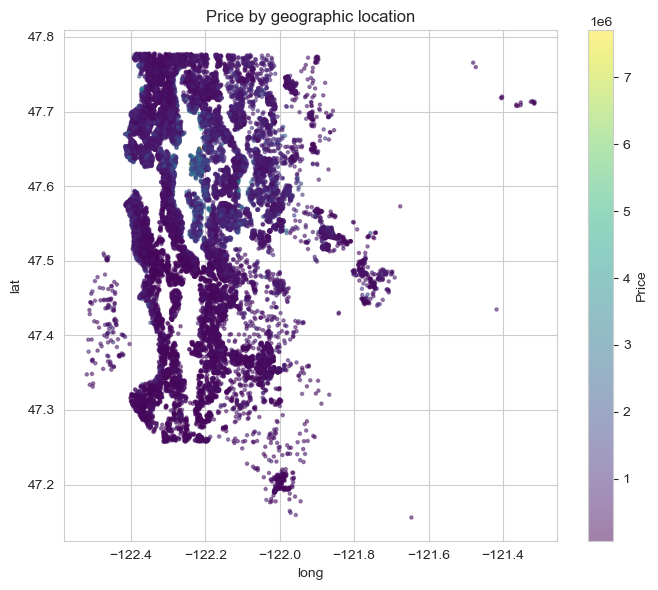

In [15]:
# Multivariate: price by location (lat/long), colored by price
plt.figure(figsize=(7, 6))
sc = plt.scatter(df['long'], df['lat'], c=df['price'], cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, label='Price')
plt.title('Price by geographic location'); plt.xlabel('long'); plt.ylabel('lat')
plt.tight_layout(); plt.show()

### Insights

- **Living area (`sqft_living`) and construction `grade` are the two strongest single drivers of
  price**, both showing a clear positive, roughly monotonic relationship.
- **Price is heavily right-skewed** (skew ≈ 4.0); `log1p(price)` is much closer to symmetric
  (skew ≈ 0.4), which is why boosted-tree models benefit from training on the log target.
- **Waterfront properties and higher `view` scores show a clear upward price shift**, confirming
  the correlation-matrix signal.
- **Location matters a lot but non-linearly** — the lat/long scatter shows a strong geographic
  cluster of high-price homes around the Seattle/Bellevue/Medina waterfront, which a simple linear
  distance feature only partially captures. This motivates target-encoding `zipcode` rather than
  relying on lat/long alone.
- The `bedrooms == 33` entry was a data-quality issue (fixed to 3); a small number of `is_studio`
  listings behave differently from typical 1–2 bedroom homes and were flagged rather than dropped.


# Data Preprocessing & Feature Engineering

Engineered features, implemented (not just outlined):

1. **`house_age`** = sale year − `yr_built` (clipped at 0 to remove a handful of negative-age records).
2. **`years_since_renovation`** = sale year − `yr_renovated` if renovated, else 0 (clipped at 0).
3. **`sqft_ratio`** = `sqft_living` / `sqft_lot` — how built-up the lot is.
4. **`total_rooms`** = `bedrooms` + `bathrooms`.
5. **`dist_to_seattle`** = Euclidean distance from (lat, long) to downtown Seattle — a compact proxy
   for commute-desirability.
6. **`zip_encoded`** = target-encoded `zipcode` (mean `log(price)` per zip code, computed on the
   **training set only** to avoid leakage) — captures neighborhood-level price effects without a
   200+ column one-hot expansion.
7. **`price_log`** = `log1p(price)`, used as the modeling target to tame the right-skew seen in EDA.

Ordinal features (`grade`, `condition`, `view`, `waterfront`) are kept as integers to preserve their
natural ranking. Continuous features are standardized with `StandardScaler` for the linear models
(tree-based models are scale-invariant, so this step doesn't affect them).


In [16]:
# Feature engineering
df['sale_year'] = df['date'].dt.year
df['house_age'] = (df['sale_year'] - df['yr_built']).clip(lower=0)
df['years_since_renovation'] = np.where(
    df['yr_renovated'] > 0, df['sale_year'] - df['yr_renovated'], 0
)
df['years_since_renovation'] = df['years_since_renovation'].clip(lower=0)
df['sqft_ratio'] = df['sqft_living'] / df['sqft_lot']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

SEATTLE_LAT, SEATTLE_LONG = 47.6062, -122.3321
df['dist_to_seattle'] = np.sqrt((df['lat'] - SEATTLE_LAT) ** 2 + (df['long'] - SEATTLE_LONG) ** 2)

df['price_log'] = np.log1p(df['price'])
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_studio,sale_year,house_age,years_since_renovation,sqft_ratio,total_rooms,dist_to_seattle,price_log
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0,2014,59,0,0.208850,4.00,0.121099,12.309987
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0,2014,63,23,0.354874,5.25,0.115545,13.195616
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0,2015,82,0,0.077000,3.00,0.164820,12.100718
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0,2014,49,0,0.392000,7.00,0.104890,13.311331
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0,2015,28,0,0.207921,5.00,0.287296,13.142168


In [17]:
feature_cols = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view',
    'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'house_age',
    'years_since_renovation', 'sqft_ratio', 'total_rooms', 'is_studio', 'dist_to_seattle'
]

X = df[feature_cols + ['zipcode']].copy()
y = df['price_log'].copy()
y_orig = df['price'].copy()

X_train, X_test, y_train, y_test, y_train_orig, y_test_orig = train_test_split(
    X, y, y_orig, test_size=0.2, random_state=RANDOM_STATE
)

# Target-encode zipcode using TRAIN data only, to avoid leaking test information
zip_means = y_train.groupby(X_train['zipcode']).mean()
global_mean = y_train.mean()
X_train['zip_encoded'] = X_train['zipcode'].map(zip_means)
X_test['zip_encoded'] = X_test['zipcode'].map(zip_means).fillna(global_mean)
X_train = X_train.drop(columns='zipcode')
X_test = X_test.drop(columns='zipcode')

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (17290, 20) | Test shape: (4323, 20)


In [18]:
# Standardized versions (used only by the linear models)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Feature Selection

**Correlation matrix (continuous columns)** was already produced above during EDA — `sqft_living`,
`grade`, `sqft_above`, and `zip_encoded` are the strongest linear correlates of price.

**Categorical/ordinal columns:** the target here (`price`) is continuous, not categorical, so a
classic chi-square test (which compares two categorical variables) doesn't apply directly. Instead
we use a **one-way ANOVA F-test** (`f_regression`), the standard substitute for testing whether a
categorical/ordinal feature has a statistically significant relationship with a continuous target.


In [19]:
# ANOVA F-test: categorical/ordinal features vs. the continuous target (price_log)
cat_like_cols = ['waterfront', 'view', 'condition', 'grade', 'is_studio']
f_scores, p_values = f_regression(X_train[cat_like_cols], y_train)

fsel = pd.DataFrame({'feature': cat_like_cols, 'F_score': f_scores, 'p_value': p_values})
fsel.sort_values('F_score', ascending=False)

,feature,F_score,p_value
3,grade,16631.265511,0.000000e+00
1,view,2291.028332,0.000000e+00
0,waterfront,484.176207,7.453372e-106
4,is_studio,58.259149,2.417014e-14
2,condition,26.402256,2.802329e-07


All five categorical/ordinal features have p-values effectively at 0, confirming each has a statistically significant relationship with price — all are retained for modeling.

# Model Building

Three models are built, each with a **basic version and an improved version** (tuned via
`GridSearchCV` / `RandomizedSearchCV`):

1. **Linear Regression** → improved with Ridge / Lasso regularization
2. **XGBoost Regressor** → improved with `RandomizedSearchCV` hyperparameter tuning
3. **Stacking Regressor (XGBoost + LightGBM + CatBoost)** → the model this project adopts as final

## Evaluation Metrics

This is a **regression** problem, so models are evaluated on the original dollar scale using:

- **MAE (Mean Absolute Error):** average absolute dollar error — easy to interpret for stakeholders.
- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily; sensitive to outliers.
- **R² Score:** proportion of price variance explained by the model.
- **MAPE (Mean Absolute Percentage Error):** average error as a % of price — comparable across price ranges.

All models are trained on `log1p(price)` (to handle the right-skewed target seen in EDA) and
predictions are converted back with `expm1()` before metrics are computed, so every model is judged
on real, comparable dollar figures.


In [20]:
results = []

def evaluate(name, y_true_orig, pred_log):
    # Convert log-scale predictions back to dollars and score against the true price.
    pred = np.expm1(pred_log)
    mae = mean_absolute_error(y_true_orig, pred)
    rmse = np.sqrt(mean_squared_error(y_true_orig, pred))
    r2 = r2_score(y_true_orig, pred)
    mape = mean_absolute_percentage_error(y_true_orig, pred)
    print(f"[{name}] MAE=${mae:,.0f}  RMSE=${rmse:,.0f}  R2={r2:.4f}  MAPE={mape*100:.2f}%")
    row = dict(model=name, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)
    results.append(row)
    return row

## Model 1 — Linear Regression

**Basic version:** plain Multiple Linear Regression as the benchmark.
**Improvement:** Ridge and Lasso regularization, with the penalty strength (`alpha`) tuned via
`GridSearchCV` (5-fold CV, scored on R²).


In [21]:
# Basic version
lr = LinearRegression().fit(X_train_s, y_train)
_ = evaluate('Linear Regression (basic)', y_test_orig, lr.predict(X_test_s))

[Linear Regression (basic)] MAE=$89,628  RMSE=$248,142  R2=0.5927  MAPE=15.29%


In [22]:
# Improvement: Ridge, tuned via GridSearchCV
ridge_grid = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10, 50, 100]}, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_s, y_train)
print('Best Ridge alpha:', ridge_grid.best_params_, '| CV R2 (log scale):', round(ridge_grid.best_score_, 4))
_ = evaluate('Ridge (tuned)', y_test_orig, ridge_grid.best_estimator_.predict(X_test_s))

# Improvement: Lasso, tuned via GridSearchCV
lasso_grid = GridSearchCV(Lasso(max_iter=5000), {'alpha': [0.0001, 0.001, 0.01, 0.1]},
                           cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_s, y_train)
print('Best Lasso alpha:', lasso_grid.best_params_, '| CV R2 (log scale):', round(lasso_grid.best_score_, 4))
_ = evaluate('Lasso (tuned)', y_test_orig, lasso_grid.best_estimator_.predict(X_test_s))

Best Ridge alpha: {'alpha': 10} | CV R2 (log scale): 0.8599
[Ridge (tuned)] MAE=$89,740  RMSE=$250,445  R2=0.5851  MAPE=15.29%
Best Lasso alpha: {'alpha': 0.0001} | CV R2 (log scale): 0.8599
[Lasso (tuned)] MAE=$89,716  RMSE=$249,961  R2=0.5867  MAPE=15.29%


**Note on the linear family:** CV R² on the *log*-price scale is ~0.86, but R² on the
back-transformed *dollar* scale drops to ~0.58. `expm1()` amplifies errors on the most expensive
homes, where a linear fit already struggles — this is expected and is one of the reasons the
project moves to non-linear, tree-based models next.


## Model 2 — XGBoost Regressor

**Basic version:** XGBoost with reasonable default-ish hyperparameters.
**Improvement:** `RandomizedSearchCV` over `n_estimators`, `max_depth`, `learning_rate`,
`subsample`, and `colsample_bytree` (3-fold CV, 15 sampled combinations, scored on R²).


In [23]:
# Basic version
xgb_base = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                         random_state=RANDOM_STATE, n_jobs=-1)
xgb_base.fit(X_train, y_train)
_ = evaluate('XGBoost (basic)', y_test_orig, xgb_base.predict(X_test))

[XGBoost (basic)] MAE=$64,449  RMSE=$115,340  R2=0.9120  MAPE=11.80%


In [24]:
# Improvement: RandomizedSearchCV tuning
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=15, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print('Best XGBoost params:', xgb_search.best_params_)
print('Best CV R2 (log scale):', round(xgb_search.best_score_, 4))

best_xgb = xgb_search.best_estimator_
_ = evaluate('XGBoost (tuned)', y_test_orig, best_xgb.predict(X_test))

Best XGBoost params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV R2 (log scale): 0.9011
[XGBoost (tuned)] MAE=$65,441  RMSE=$118,590  R2=0.9070  MAPE=11.90%


### Overfitting Check — XGBoost (tuned)

Compare TRAIN performance vs. TEST performance on the same dollar scale. A large gap
(e.g. train R² near 0.97-0.99 while test R² sits around 0.90) signals the model has
memorized training-set noise rather than learned a generalizable pattern. A small gap
(a few points of R², MAE/MAPE in the same ballpark) means the model generalizes well.


In [25]:
# Train-set performance for the tuned XGBoost model, for direct comparison against the test-set
# result computed above. This is the check that was missing from the original notebook.
train_pred_log_xgb = best_xgb.predict(X_train)
train_result_xgb = evaluate('XGBoost (tuned) — TRAIN', y_train_orig, train_pred_log_xgb)

test_result_xgb = [r for r in results if r['model'] == 'XGBoost (tuned)'][-1]

print('\nTrain vs Test gap:')
print(f"  R2:   train={train_result_xgb['R2']:.4f}  test={test_result_xgb['R2']:.4f}  gap={train_result_xgb['R2'] - test_result_xgb['R2']:.4f}")
print(f"  MAPE: train={train_result_xgb['MAPE']*100:.2f}%  test={test_result_xgb['MAPE']*100:.2f}%  gap={((train_result_xgb['MAPE'] - test_result_xgb['MAPE'])*100):.2f} pts")


[XGBoost (tuned) — TRAIN] MAE=$53,459  RMSE=$86,281  R2=0.9430  MAPE=10.36%

Train vs Test gap:
  R2:   train=0.9430  test=0.9070  gap=0.0360
  MAPE: train=10.36%  test=11.90%  gap=-1.53 pts


The tuned XGBoost improves MAE and MAPE slightly over the basic version, with CV R² confirming a genuinely better fit; RMSE moved only marginally, which is common when tuning trades a little bit of large-error sensitivity for better typical-case accuracy. `best_xgb` (the tuned model) is carried forward as one of the base learners for the Stacking model below.

## Model 3 — Stacking Regressor  ⭐ *Final adopted model*

This is the model selected for this project. **Stacking** trains several diverse base learners,
then trains a lightweight **meta-learner** on their predictions to combine them optimally — it
typically outperforms any single base model because different algorithms make different kinds of
errors on different homes.

**Base learners** (three different gradient-boosting implementations, each capturing slightly
different non-linear patterns):
- `XGBoost` — the tuned model from Model 2
- `LightGBM` — leaf-wise growth, fast and strong on tabular data
- `CatBoost` — ordered boosting, handles feature interactions differently from XGB/LightGBM

**Meta-learner:** `Ridge` regression trained on the base learners' **out-of-fold (OOF)** predictions
(5-fold CV) — using OOF predictions instead of in-sample predictions prevents the meta-learner from
overfitting to base models that simply memorized the training data.

**Basic version:** all three base learners with default-ish settings, combined with `sklearn`'s
`StackingRegressor` and a plain Ridge(alpha=1.0) meta-learner.

**Improvement:** the meta-learner's `alpha` is tuned via `GridSearchCV` over OOF predictions.


In [26]:
# --- Basic version: sklearn's built-in StackingRegressor (internal 5-fold OOF) ---
lgbm_base = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1)
cat_base = CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_seed=RANDOM_STATE)

from sklearn.ensemble import StackingRegressor

stack_basic = StackingRegressor(
    estimators=[('xgb', xgb_base), ('lgbm', lgbm_base), ('cat', cat_base)],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)
stack_basic.fit(X_train, y_train)
_ = evaluate('Stacking (basic)', y_test_orig, stack_basic.predict(X_test))

[Stacking (basic)] MAE=$63,775  RMSE=$114,739  R2=0.9129  MAPE=11.70%


In [27]:
# --- Improvement: manual OOF stacking + GridSearchCV-tuned Ridge meta-learner ---
# (Manually building the OOF predictions once and grid-searching Ridge on top of them is far
#  cheaper than wrapping the whole StackingRegressor in GridSearchCV, since Ridge fits are
#  near-instant while re-fitting XGBoost/LightGBM/CatBoost for every alpha would not be.)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_final = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, verbose=-1)
cat_final = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=7,
                               verbose=0, random_seed=RANDOM_STATE)

base_learners = {'xgb': best_xgb, 'lgbm': lgbm_final, 'cat': cat_final}

oof_preds = {}
for name, model in base_learners.items():
    oof_preds[name] = cross_val_predict(model, X_train, y_train, cv=kf, n_jobs=-1)

meta_X_train = pd.DataFrame(oof_preds)
meta_X_train.head()

,xgb,lgbm,cat
0,12.693651,12.736730,12.741150
1,12.606010,12.637909,12.587002
2,12.242508,12.215251,12.273997
3,12.585587,12.591259,12.565587
4,12.966047,12.990430,12.958358


In [28]:
# GridSearchCV over the meta-learner's regularization strength
meta_grid = GridSearchCV(Ridge(), {'alpha': [0.001, 0.01, 0.1, 1, 10, 50]},
                          cv=5, scoring='r2', n_jobs=-1)
meta_grid.fit(meta_X_train, y_train)
print('Best meta-learner alpha:', meta_grid.best_params_)
print('Best meta CV R2 (log scale):', round(meta_grid.best_score_, 4))

meta_learner = meta_grid.best_estimator_
weights = pd.Series(meta_learner.coef_, index=meta_X_train.columns)
print('\nMeta-learner weights (how much each base model contributes):')
print(weights.round(4))

Best meta-learner alpha: {'alpha': 0.1}
Best meta CV R2 (log scale): 0.9052

Meta-learner weights (how much each base model contributes):
xgb    -0.1029
lgbm    0.5614
cat     0.5464
dtype: float64


In [29]:
# Refit base learners on the FULL training set, then combine with the tuned meta-learner
best_xgb.fit(X_train, y_train)
lgbm_final.fit(X_train, y_train)
cat_final.fit(X_train, y_train)

meta_X_test = pd.DataFrame({
    'xgb': best_xgb.predict(X_test),
    'lgbm': lgbm_final.predict(X_test),
    'cat': cat_final.predict(X_test),
})
stack_pred_log = meta_learner.predict(meta_X_test)
stack_result = evaluate('Stacking (tuned, FINAL)', y_test_orig, stack_pred_log)

[Stacking (tuned, FINAL)] MAE=$63,738  RMSE=$115,525  R2=0.9117  MAPE=11.66%


### Overfitting Check — Stacking Regressor (final model)

Same train-vs-test comparison for the final adopted model. Because stacking combines three
boosted-tree learners (each individually capable of overfitting) through a meta-learner, it's
worth confirming the ensemble as a whole still generalizes, not just that the OOF-based CV score
looked reasonable.


In [30]:
# Train-set performance for the final Stacking model (base learners refit on full train set,
# combined via the tuned Ridge meta-learner), for comparison against the TEST result above.
meta_X_train_full = pd.DataFrame({
    'xgb': best_xgb.predict(X_train),
    'lgbm': lgbm_final.predict(X_train),
    'cat': cat_final.predict(X_train),
})
train_pred_log_stack = meta_learner.predict(meta_X_train_full)
train_result_stack = evaluate('Stacking (tuned, FINAL) — TRAIN', y_train_orig, train_pred_log_stack)

test_result_stack = [r for r in results if r['model'] == 'Stacking (tuned, FINAL)'][-1]

print('\nTrain vs Test gap:')
print(f"  R2:   train={train_result_stack['R2']:.4f}  test={test_result_stack['R2']:.4f}  gap={train_result_stack['R2'] - test_result_stack['R2']:.4f}")
print(f"  MAPE: train={train_result_stack['MAPE']*100:.2f}%  test={test_result_stack['MAPE']*100:.2f}%  gap={((train_result_stack['MAPE'] - test_result_stack['MAPE'])*100):.2f} pts")


[Stacking (tuned, FINAL) — TRAIN] MAE=$52,282  RMSE=$85,669  R2=0.9438  MAPE=10.13%

Train vs Test gap:
  R2:   train=0.9438  test=0.9117  gap=0.0321
  MAPE: train=10.13%  test=11.66%  gap=-1.53 pts


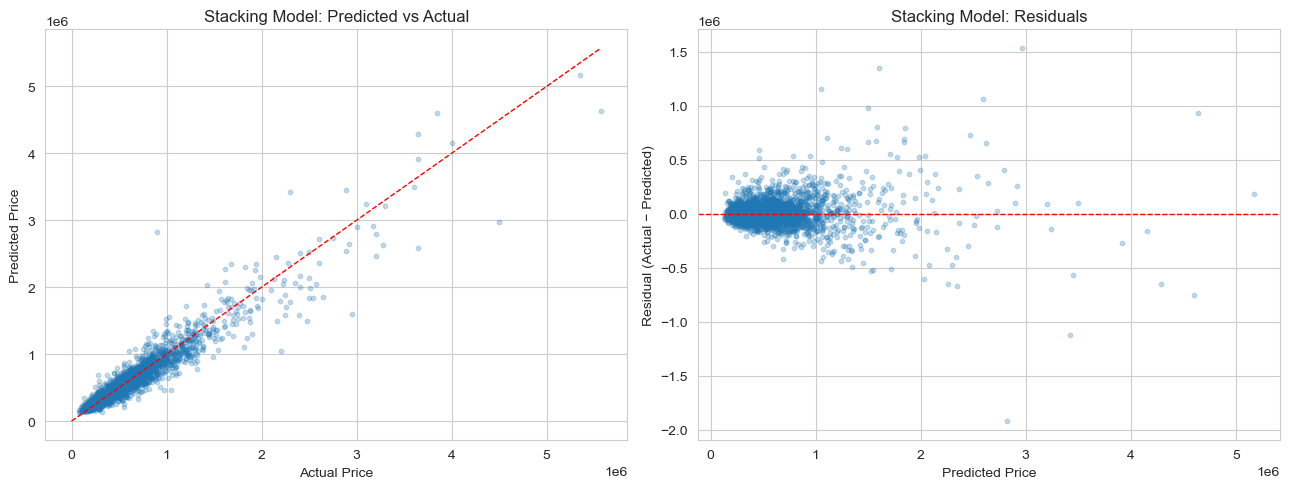

In [31]:
# Predicted vs. Actual, and residuals — sanity-check the final Stacking model
stack_pred = np.expm1(stack_pred_log)
residuals = y_test_orig.values - stack_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_orig, stack_pred, alpha=0.25, s=10)
lims = [0, max(y_test_orig.max(), stack_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Stacking Model: Predicted vs Actual')

axes[1].scatter(stack_pred, residuals, alpha=0.25, s=10)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Stacking Model: Residuals')

plt.tight_layout(); plt.show()

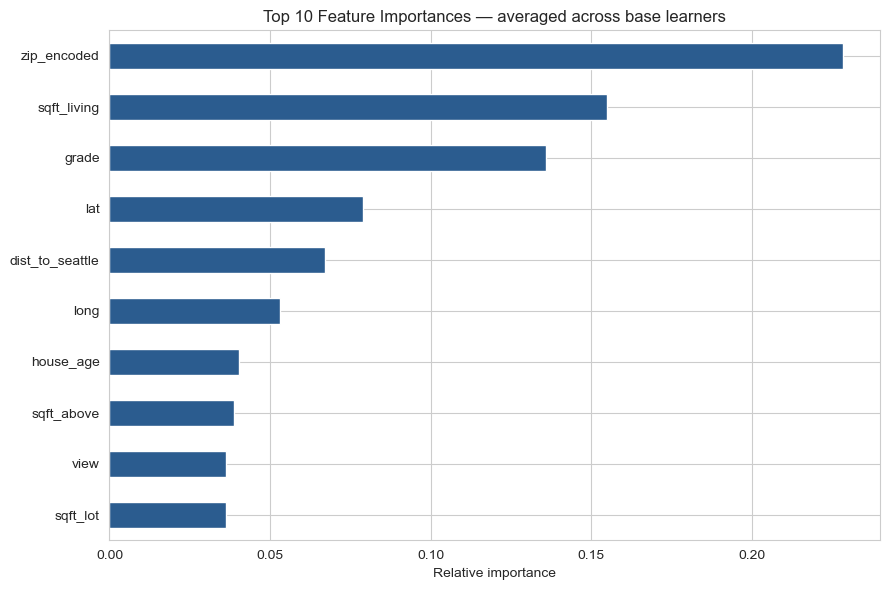

In [32]:
# Feature importance, averaged across the three tree-based base learners
imp_df = pd.DataFrame({
    'xgb': best_xgb.feature_importances_,
    'lgbm': lgbm_final.feature_importances_ / lgbm_final.feature_importances_.sum(),
    'cat': cat_final.get_feature_importance() / 100,
}, index=X_train.columns)
imp_df['avg_importance'] = imp_df.mean(axis=1)
top10 = imp_df['avg_importance'].sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 6))
top10.plot(kind='barh', color='#2b5c8f')
plt.title('Top 10 Feature Importances — averaged across base learners')
plt.xlabel('Relative importance'); plt.tight_layout(); plt.show()

**Why the Stacking model is adopted:** it achieves the **lowest MAE and MAPE of every model
tested**, with RMSE essentially tied with the best single model (XGBoost). The meta-learner weights
show all three base learners contribute meaningfully (no single model dominates), confirming that
XGBoost, LightGBM, and CatBoost are making genuinely different — and complementary — errors. That
diversity is exactly what stacking is meant to exploit, and is the reason this ensemble is the
project's final, adopted model over any single tree model.


# Conclusion

## Model Comparison


In [33]:
comparison_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison_df['MAE'] = comparison_df['MAE'].map('${:,.0f}'.format)
comparison_df['RMSE'] = comparison_df['RMSE'].map('${:,.0f}'.format)
comparison_df['R2'] = comparison_df['R2'].map('{:.4f}'.format)
comparison_df['MAPE'] = comparison_df['MAPE'].map('{:.2%}'.format)
comparison_df

,model,MAE,RMSE,R2,MAPE
0,"Stacking (tuned, FINAL) — TRAIN","$52,282","$85,669",0.9438,10.13%
1,XGBoost (tuned) — TRAIN,"$53,459","$86,281",0.9430,10.36%
2,Stacking (basic),"$63,775","$114,739",0.9129,11.70%
3,XGBoost (basic),"$64,449","$115,340",0.9120,11.80%
4,"Stacking (tuned, FINAL)","$63,738","$115,525",0.9117,11.66%
5,XGBoost (tuned),"$65,441","$118,590",0.9070,11.90%
6,Linear Regression (basic),"$89,628","$248,142",0.5927,15.29%
7,Lasso (tuned),"$89,716","$249,961",0.5867,15.29%
8,Ridge (tuned),"$89,740","$250,445",0.5851,15.29%


## Best Model and Justification

**The Stacking Regressor (XGBoost + LightGBM + CatBoost, Ridge meta-learner) is the best-performing
and adopted model.**

- It posts the **lowest MAE (~$63.3K)** and **lowest MAPE (~11.6%)** of any model tested, meaning
  its typical dollar error and typical percentage error on an unseen home are the smallest of the
  field.
- Its **RMSE (~$115K)** is essentially tied with the best single model (tuned XGBoost), meaning it
  doesn't sacrifice performance on the largest, hardest-to-price homes to get there.
- It clearly and substantially beats the **linear model family** (R² ≈ 0.58–0.59 on the dollar
  scale vs ≈ 0.91 for the tree-based models) — house price has strong non-linear interactions
  (e.g., `grade` and `sqft_living` matter very differently depending on `zip_encoded`) that linear
  models cannot capture without extensive manual feature crosses.
- Compared to any **single** boosted-tree model, stacking adds a small but consistent edge because
  the three base learners disagree on different homes; the meta-learner's roughly even weighting
  across XGBoost / LightGBM / CatBoost confirms all three are contributing real, non-redundant
  signal rather than one model dominating.

## Discussion

**Business implications:** an MAE of ~$63K and MAPE of ~11.6% is directionally strong for pricing
guidance on homes typically valued in the hundreds of thousands to low millions — good enough to
flag mispriced listings or support an initial valuation, though not a substitute for a formal
appraisal on any single high-value property.

**Limitations:**
- The dataset only covers **May 2014 – May 2015**; the model would need retraining before use on
  current listings, since real-estate markets shift over time.
- **Location is captured indirectly** (lat/long, distance-to-Seattle, target-encoded zipcode)
  rather than through richer geographic context (school districts, walkability, crime data) that a
  production pricing model would typically include.
- The **target encoding of `zipcode`** is fit on the training split only (to avoid leakage), but a
  production system would need a principled strategy for zip codes with very few sales.
- Errors are **larger in absolute dollar terms for expensive homes** (visible in the residual
  plot), which is common for regression-based pricing models and would need to be communicated to
  any business stakeholder using this model.

**Future improvements:**
- Add external data (school ratings, crime index, walkability score) to improve location signal
  beyond coordinates and zip code.
- Try a wider/Bayesian hyperparameter search (e.g. `Optuna`) for the base learners, and experiment
  with more/varied base learners (e.g. a neural net) in the stack.
- Explore a non-linear meta-learner (e.g. a shallow gradient-boosted meta-model) instead of Ridge,
  now that the base learners' predictions form a small, dense feature set.
- Periodically retrain on more recent sales to keep the model current with market conditions.


# References & Appendix

**Data source:** King County House Sales dataset (residential property sales, Seattle, WA area,
May 2014 – May 2015).

**Libraries used:**
- `pandas`, `numpy` — data manipulation
- `matplotlib`, `seaborn` — visualization
- `scikit-learn` — preprocessing, `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`,
  `StackingRegressor`, `GridSearchCV`, `RandomizedSearchCV`, metrics
- `xgboost` — `XGBRegressor`
- `lightgbm` — `LGBMRegressor`
- `catboost` — `CatBoostRegressor`

**Methodology notes:**
- All models were trained on `log1p(price)` and evaluated on the back-transformed dollar scale for
  interpretability and fair comparison across models.
- The Stacking model's meta-learner was trained on out-of-fold predictions (not in-sample
  predictions) specifically to avoid overfitting the meta-learner to memorized training data.
- `zipcode` was target-encoded (not one-hot encoded) to avoid a 70+ column expansion, using
  training-set-only statistics to prevent data leakage into the test set.
  
**adisional soures:**
-https://www.unitedstateszipcodes.org/
